In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 


In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [7]:
# build the voacabulary of characters and mapping to/from integers 
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [9]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
    
import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

    

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [11]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [13]:
# let's train the deep neural network 
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps 
        self.momentum = momentum 
        self.training = True     # making sure training is true by default like in pytorch
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim) # weights 
        self.beta = torch.zeros(dim) # bias 
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_std = torch.ones(dim) 

    def __call__(self, x):
        # calculate forward pass 
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean 
            xvar = x.var(0, keepdim=True)   # batch variance 
        else: 
            xmean = self.running_mean
            xvar = self.running_var 
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance 
        self.out = xhat * self.gamma + self.beta 
        # update buffers 
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean 
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar 
        return self.out 
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out 
    def parameters(self):
        return []
        
        
n_embd = 10 # dimensionality of the character embedding vectors 
n_hidden = 100 # the no of neurons in the hidden layer of MLP 
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)

# list of layers of neurons 
layers=[
    Linear(n_embd * block_size, n_hidden), Tanh(), 
    Linear( n_hidden, n_hidden), Tanh(),
    Linear( n_hidden, n_hidden), Tanh(),
    Linear( n_hidden, n_hidden), Tanh(),
    Linear( n_hidden, n_hidden), Tanh(),
    Linear( n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident 
    layers[-1].weight +=0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight += 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total 
for p in parameters:
    p.requires_grad=True

        

46497


In [15]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # mini batch

    # forward pass 
    emb = C[Xb] # embed the chaarcters into vectors 
    x = emb.view(emb.shape[0], -1) # concatenate the vectors 
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function 


    # backward pass 
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update 
    #lr = lrs[i]
    lr = 0.01 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    # track 
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
     
    lossi.append(loss.log10().item())

    
    
print(loss.item())


      0/ 200000: 3.7749
  10000/ 200000: 2.9458
  20000/ 200000: 2.7150
  30000/ 200000: 2.6044
  40000/ 200000: 2.8026
  50000/ 200000: 2.8147
  60000/ 200000: 2.7958
  70000/ 200000: 2.7723
  80000/ 200000: 3.0139
  90000/ 200000: 3.0036
 100000/ 200000: 2.8258
 110000/ 200000: 2.8281
 120000/ 200000: 2.8474
 130000/ 200000: 2.5197
 140000/ 200000: 2.5334
 150000/ 200000: 2.7057
 160000/ 200000: 3.0873
 170000/ 200000: 2.7535
 180000/ 200000: 2.8911
 190000/ 200000: 2.6763
2.9159369468688965


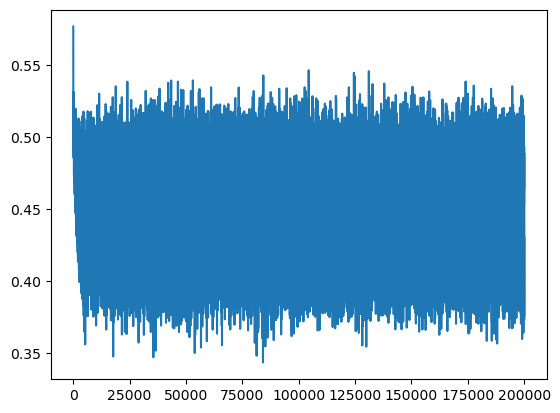

In [16]:
plt.plot(lossi) 
plt.show()

In [19]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [21]:
@torch.no_grad() 
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 #+ b1
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias 
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias 
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 3.3020427227020264
val 3.300964117050171


In [ ]:
# loss log 

# fix softmax confidentally wrong:
train 2.143939733505249
val 2.1826694011688232

# fix tanh layer too saturated at init:
train 2.097454071044922
val 2.1343514919281006

# add a batch norm layer 
train 2.129476547241211
val 2.1524288654327393

# after adding bnmean_running and bnstd_running
train 2.129281997680664
val 2.1519393920898438

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      h = torch.tanh(embcat @ W1 + b1)
      
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word
    